In [70]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D,Flatten,MaxPool2D
from keras.datasets import mnist

In [46]:
(X_tr,y_tr),(X_tst,y_tst) = mnist.load_data() 
X_tr = X_tr/255
X_tst = X_tst/255

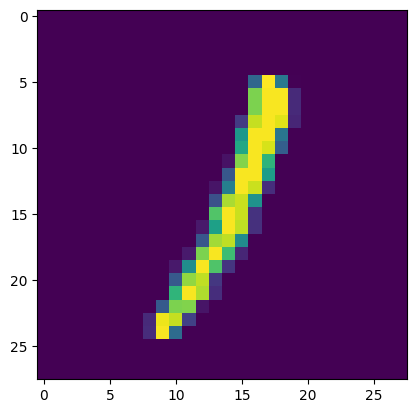

In [47]:
import matplotlib.pyplot as plt 
plt.imshow(X_tr[99])
plt.show()

In [71]:
from IPython.core import pylabtools
## With no padding

model = Sequential()
model.add(Conv2D(32,kernel_size= (3,3),padding='valid',activation ='relu',input_shape = (28,28,1) ))
model.add(MaxPool2D(pool_size= (2,2),strides = 2,padding = 'valid'))
model.add(Conv2D(32,kernel_size=(3,3),padding = 'valid',activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=2,padding = 'valid'))
model.add(Conv2D(32,kernel_size = (3,3),padding = 'valid',activation='relu'))
model.add(MaxPool2D(pool_size = (2,2),strides = 2,padding = 'valid'))

model.add(Flatten())

model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation = 'softmax'))


c:\Users\Krish\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [72]:

## Here hw will see infor loss at Conv layers 
model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_47 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 3, 3, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,202 (78.91 KB)

 Trainable params: 20,202 (78.91 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
## With padding 

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='same',activation='relu',input_shape = (28,28,1)))
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='same'))
model.add(Conv2D(32,kernel_size=(3,3),padding = 'same',activation = 'relu'))
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='same'))
model.add(Conv2D(32,kernel_size=(3,3),padding = 'same',activation = 'relu',))
model.add(MaxPool2D(pool_size=(2,2),strides = 2,padding = 'same'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

c:\Users\Krish\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [74]:
model.fit(X_tr,y_tr,validation_split= 0.2)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 0.1840 - sparse_categorical_accuracy: 0.9416 - val_loss: 0.0617 - val_sparse_categorical_accuracy: 0.9818


In [75]:
pred = model.predict(X_tst)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [76]:
import numpy as np
y_pred = np.argmax(pred,axis=1)

In [77]:
from sklearn.metrics import accuracy_score,classification_report

In [78]:
print(accuracy_score(y_pred,y_tst))
print(classification_report(y_pred,y_tst))

0.9837
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       963
           1       1.00      0.99      0.99      1145
           2       0.99      0.98      0.98      1046
           3       0.99      0.99      0.99      1012
           4       0.99      0.99      0.99       981
           5       0.99      0.98      0.99       899
           6       0.99      0.97      0.98       986
           7       0.99      0.97      0.98      1042
           8       0.96      0.99      0.97       948
           9       0.96      0.99      0.98       978

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



np.int64(1288)